농어(Perch)의 무게 예측

* 농어의 모든 특성들을 사용한 무게 예측
  * Weight ~ Length + Diagonal + Height + Width
* KNN Regressor과 Linear Regression비교
* 다차항들을 포함하는 회귀
* 규제(Regularization)  

# Imports

In [1]:
# Regularization(규제)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler # 다차항
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge,Lasso, ElasticNet # 선형회귀 변종 규제를 포함하는 3가지
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error # 평가

# Fish 데이터셋

In [2]:
file_path='https://bit.ly/fish_csv_data'

In [3]:
fish=pd.read_csv(file_path)

In [4]:
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [5]:
perch=fish[fish.Species=='Perch']

In [6]:
perch.head()

,Species,Weight,Length,Diagonal,Height,Width
72,Perch,5.9,8.4,8.8,2.1120,1.4080
73,Perch,32.0,13.7,14.7,3.5280,1.9992
74,Perch,40.0,15.0,16.0,3.8240,2.4320
75,Perch,51.5,16.2,17.2,4.5924,2.6316
76,Perch,70.0,17.4,18.5,4.5880,2.9415


In [7]:
perch.columns[2:] # 배열 슬라이싱

Index(['Length', 'Diagonal', 'Height', 'Width'], dtype='object')

In [8]:
# perch[perch.columns[2:]]
x=perch[perch.columns[2:]].values
x.shape #(56,4) = (n_samples, n_features)

(56, 4)

In [9]:
# perch_input=perch[['Length','Diagonal','Height','Width']].to_numpy() .to_numpy()가 더 안정적
# perch_input

In [10]:
y=perch['Weight'].values # 타겟 배열
y.shape #(56,) = (n_samples,)

(56,)

## 훈련 셋, 테스트 셋 나누기

In [11]:
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [12]:
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((42, 4), (42,), (14, 4), (14,))

In [13]:
x_train[:5] # 5번까지의 물고기의 특성

array([[19.6   , 20.8   ,  5.1376,  3.0368],
       [22.    , 23.5   ,  5.875 ,  3.525 ],
       [18.7   , 19.4   ,  5.1992,  3.1234],
       [17.4   , 18.5   ,  4.588 ,  2.9415],
       [36.    , 38.3   , 10.6091,  6.7408]])

In [14]:
y_train[:5] # 5번까지의 물고기의 타겟(무게)

array([ 85., 135.,  78.,  70., 700.])

# 1차항만 포함하는 회귀

Weight ~ Length + Diagonal + Height + Width(무게 예측)

## KNN 으로 첫번째 예측

In [15]:
knn=KNeighborsRegressor() # KNN 회귀 모델 생성

In [16]:
knn.fit(X=x_train,y=y_train) # 모델 훈련

KNeighborsRegressor()

In [17]:
train_pred=knn.predict(X=x_train)
train_pred # 훈련 셋에서 예측 값 계산 k=5개로

array([  87.6,  123. ,   79.6,   70.6,  723. ,  183.4,  847. ,  847. ,
       1020. ,  123. ,   95. ,  123. ,  174. ,  248. , 1043. ,  847. ,
        174. ,  122. ,  248. ,  847. ,  582. ,  224. ,  723. ,   60. ,
        142. ,   60. ,  685. ,  694.2,  248. ,  167. ,  847. ,  122. ,
        139. ,  123. , 1020. ,  136. ,   79.6,  685. ,  123. ,  193. ,
       1043. ,  659. ])

In [18]:
y_train #실제 값

array([  85.,  135.,   78.,   70.,  700.,  180.,  850.,  820., 1000.,
        120.,   85.,  130.,  225.,  260., 1100.,  900.,  145.,  115.,
        265., 1015.,  514.,  218.,  685.,   32.,  145.,   40.,  690.,
        840.,  300.,  170.,  650.,  110.,  150.,  110., 1000.,  150.,
         80.,  700.,  120.,  197., 1100.,  556.])

In [19]:
test_pred=knn.predict(X=x_test)
test_pred # 테스트 셋에서의 예측값

array([  60. ,   79.6,  248. ,  122. ,  130. ,  847. ,  311.4,  183.4,
        847. ,  118. , 1043. ,   60. ,  248. ,  248. ])

In [20]:
y_test # y들은 실제값이다

array([   5.9,  100. ,  250. ,  130. ,  130. ,  820. ,  320. ,  188. ,
        900. ,  125. , 1000. ,   51.5,  250. ,  300. ])

### KNN 모델 평가

In [21]:
#훈련 셋의 MSE
mean_squared_error(y_true=y_train,y_pred=train_pred)

2986.5723809523806

In [22]:
# 테스트 셋의 MSE
mean_squared_error(y_true=y_test,y_pred=test_pred) # 점수가 낮을수록 좋고 테스트 > 훈련 인경우 과소적합이닫

837.3100000000001

KNN은 과소적합 - 테스트 셋의 성능이 훈련 셋의 성능보다 좋다.

In [23]:
# 훈련 셋의 결정계수(R2 score) score의 역할 분류는 정확도 회귀는 결정계수
knn.score(X=x_train,y=y_train)

0.97579760182756

In [24]:
knn.score(X=x_test,y=y_test)

0.9916579819676246

In [25]:
# bias를 넣으면 기울기에 인터셉트가 들어간다고?
# bias=True 하면 인터셉트가 coef(가중치)랑 “합쳐지는 게 아니라”
# 입력 행렬 X에 1열을 추가하고, 그 1열에 대응하는 coef가 intercept 역할을 한다.
#
#
#

**TODO**

StandardScaler와 KNeighborsRegressor를 Pipeline을 연결한 모델을 생성, 훈련, 예측, 평가

표준화를 하지 않았을 때와 비교.

#Linear Regression

$$
\hat{y} = w_0 + x_1 \times w_1 + x_2 \times w_2 + x_3 \times w_3 + x_4 \times w_4
$$
예측값 = 상수항 +  컬럼 기울기 4개 *

선형 회귀식에서 예측한 값들의 MSE가 최소가 되는 $w_0$ ~ $w_4$를 찾는 과정.
이 Linear Regression

In [26]:
lin_reg=LinearRegression() # 선형회귀 ML 모델 생성

In [27]:
lin_reg.fit(X=x_train,y=y_train) # 모델 훈련

LinearRegression()

In [28]:
lin_reg.coef_ # (기울기) 계수값

array([-40.18338554,  47.80681727,  67.34086612,  35.34904264])

In [29]:
lin_reg.intercept_ # 절편값

np.float64(-610.0275364260515)

In [30]:
train_pred=lin_reg.predict(X=x_train) # 훈련 셋 예측값 찾기
train_pred

array([  50.07831254,  149.63115115,   26.52323981,  -11.85322276,
        727.07849472,  216.11818851,  859.35210445,  894.24144157,
        883.76216601,  133.80604761,   30.46174313,  165.45625469,
        267.36647321,  302.42993565,  942.06583292,  859.73196835,
        209.15316045,  137.18128947,  294.64533152,  907.16858502,
        585.54863062,  292.8893912 ,  763.11655759, -149.53132283,
        163.94525857, -104.38889956,  718.95576629,  815.95759166,
        350.34538816,  195.07245372,  764.17125484,  130.77848264,
        116.61555757,  142.50754589,  959.21205119,  218.69399647,
         79.52715018,  737.86169572,  161.30274218,  243.72987423,
        939.22223984,  665.0680958 ])

In [31]:
y_train

array([  85.,  135.,   78.,   70.,  700.,  180.,  850.,  820., 1000.,
        120.,   85.,  130.,  225.,  260., 1100.,  900.,  145.,  115.,
        265., 1015.,  514.,  218.,  685.,   32.,  145.,   40.,  690.,
        840.,  300.,  170.,  650.,  110.,  150.,  110., 1000.,  150.,
         80.,  700.,  120.,  197., 1100.,  556.])

### 선형 회귀 모델 평가

In [32]:
mean_squared_error(y_true=y_train,y_pred=train_pred) # 훈련 셋 MSE

5340.176566753986

In [33]:
lin_reg.score(X=x_train,y=y_train) # 훈련 셋 결정계수 r2

0.9567246116638569

In [34]:
lin_reg.score(x_test,y_test) # 테스트 셋 결정계수 r2

0.8790465615990273

선형회귀 모델은 과대적합 - 훈련 셋의 점수가 테스트 셋의 점수보다 높음.

선형회귀 모델이 KNN보다 성능이 나쁨.

# 2차항을 포함하는 회귀

## KNN

In [35]:
# 다차항 파생변수들을 생성하는 전처리기 생성
poly=PolynomialFeatures(include_bias=False)
# degree=2 (기본값): 숫자 만큼 항을만든다.
# interaction_only=False(기본값): 각 컬럼끼리 디그리계수 만들어주는거 2차항만들다끝남
# include_bias=True(기본값): 편향(bias)를 포함 4+ 10 False 4+ 10 +1
# poly=PolynomialFeatures(include_bias=False)

In [36]:
poly.fit_transform(x_train)[:5]

array([[  19.6       ,   20.8       ,    5.1376    ,    3.0368    ,
         384.16      ,  407.68      ,  100.69696   ,   59.52128   ,
         432.64      ,  106.86208   ,   63.16544   ,   26.39493376,
          15.60186368,    9.22215424],
       [  22.        ,   23.5       ,    5.875     ,    3.525     ,
         484.        ,  517.        ,  129.25      ,   77.55      ,
         552.25      ,  138.0625    ,   82.8375    ,   34.515625  ,
          20.709375  ,   12.425625  ],
       [  18.7       ,   19.4       ,    5.1992    ,    3.1234    ,
         349.69      ,  362.78      ,   97.22504   ,   58.40758   ,
         376.36      ,  100.86448   ,   60.59396   ,   27.03168064,
          16.23918128,    9.75562756],
       [  17.4       ,   18.5       ,    4.588     ,    2.9415    ,
         302.76      ,  321.9       ,   79.8312    ,   51.1821    ,
         342.25      ,   84.878     ,   54.41775   ,   21.049744  ,
          13.495602  ,    8.65242225],
       [  36.        ,   38.

In [37]:
scaler=StandardScaler() # 표준화 변수 스케일링을 하는 전처리기 생성
# scaler=StandardScaler()

In [38]:
# ML 모델 생성
knn=KNeighborsRegressor()

In [39]:
# 변환기 + 추정기 >> 파이프라인
pipe = Pipeline(steps=[('poly',poly),('scaler',scaler),('regressor',knn)])

In [40]:
# 모델 훈련
pipe.fit(X=x_train,y=y_train)

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('scaler', StandardScaler()),
                ('regressor', KNeighborsRegressor())])

In [41]:
pipe['poly'].get_feature_names_out()

array(['x0', 'x1', 'x2', 'x3', 'x0^2', 'x0 x1', 'x0 x2', 'x0 x3', 'x1^2',
       'x1 x2', 'x1 x3', 'x2^2', 'x2 x3', 'x3^2'], dtype=object)

Pipeline의 `fit` 메서드 동작:
1. PolynomialFeatures 객체에서 `fit_tranform` - 2차항들이 포함.
2. StandardScaler 객체에서 `fit_transform` - 훈련 셋의 평균과 표준편차를 찾아서 스케일 변환을 수행.
3. KNeighborsRegressor 객체에서 `fit` - KNN 모델 훈련

In [42]:
train_pred=pipe.predict(X=x_train)

In [43]:
train_pred

array([  79.6,  130. ,   79.6,   79.6,  666.2,  183.4,  937. ,  937. ,
       1043. ,  123. ,   79.6,  130. ,  174. ,  248. , 1043. ,  917. ,
        158. ,  120. ,  248. ,  937. ,  632. ,  224. ,  666.2,   61. ,
        130. ,   61. ,  685. ,  789. ,  248. ,  158. ,  685. ,  122. ,
        132. ,  132. , 1043. ,  143. ,   88.6,  685. ,  130. ,  201. ,
       1013. ,  632. ])

In [44]:
y_train

array([  85.,  135.,   78.,   70.,  700.,  180.,  850.,  820., 1000.,
        120.,   85.,  130.,  225.,  260., 1100.,  900.,  145.,  115.,
        265., 1015.,  514.,  218.,  685.,   32.,  145.,   40.,  690.,
        840.,  300.,  170.,  650.,  110.,  150.,  110., 1000.,  150.,
         80.,  700.,  120.,  197., 1100.,  556.])

In [45]:
#테스트 예측값구하기

### 2차항을 고려한 KNN 모델 평가

In [46]:
pipe.score(X=x_train,y=y_train) #훈련 셋에서의 결정계수

0.9852536214139073

In [47]:
pipe.score(X=x_test,y=y_test) #테스트 셋에서의 결정계수

0.9861441832656344

1차항들만 사용한 KNN보다 2차항까지 사용한 KNN이 훈련 셋 점수가 더 좋음.

1차항들만 사용한 KNN은 과소적합이 크게 나타났지만, 2차항까지 사용한 KNN은 과소적합이 거의 없다.

In [48]:
knn.kneighbors(n_neighbors=5)

(array([[0.20414641, 0.2461952 , 0.25099311, 0.55035678, 0.56890576],
        [0.1119555 , 0.11306095, 0.1415081 , 0.19296581, 0.24382661],
        [0.24252025, 0.2461952 , 0.38567306, 0.40147491, 0.71609127],
        [0.40147491, 0.55035678, 0.58803567, 0.61054467, 0.717661  ],
        [0.33480774, 0.48732883, 0.60311503, 0.75543097, 1.24835864],
        [0.25638929, 0.36683301, 0.47459848, 0.50729384, 0.59629199],
        [0.19708652, 0.54304575, 0.57995766, 1.03801747, 1.06002127],
        [0.3897965 , 0.54304575, 0.60717718, 1.19383763, 1.33300878],
        [0.50140198, 0.81135033, 0.82200087, 1.00343384, 1.02228735],
        [0.1119555 , 0.21993826, 0.22500812, 0.23775373, 0.25017652],
        [0.20414641, 0.36611622, 0.38567306, 0.58803567, 0.6606983 ],
        [0.09265712, 0.11306095, 0.19265723, 0.22500812, 0.30989834],
        [0.46806259, 0.46813324, 0.47459848, 0.53919232, 0.66934991],
        [0.061476  , 0.30500613, 0.51142242, 0.60945484, 0.97810816],
        [0.46124432,

# 2차항을 포함하는 선형회귀

In [49]:
lin_reg=LinearRegression()

In [50]:
# 변환기 + 추정기 >> 파이프라인
pipe = Pipeline(steps=[('poly',poly),('scaler',scaler),('lin_reg',lin_reg)])
# pipe=Pipeline(steps=[('poly',PolynomialFeatures(include_bias=False)),('scaler',StandardScaler()),('regressor',LinearRegression())])

In [51]:
pipe.fit(X=x_train,y=y_train) # 모델 훈련

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('scaler', StandardScaler()), ('lin_reg', LinearRegression())])

In [52]:
pipe['poly'].get_feature_names_out()
#> 기존 훈련 셋의 모양은 (42, 4). 2차항들이 포함된 훈련 셋은(42,14).

array(['x0', 'x1', 'x2', 'x3', 'x0^2', 'x0 x1', 'x0 x2', 'x0 x3', 'x1^2',
       'x1 x2', 'x1 x3', 'x2^2', 'x2 x3', 'x3^2'], dtype=object)

In [53]:
pipe['scaler'].mean_ # 2차항들이 포함된 14개 특성의 평균.

array([ 28.4452381 ,  30.16190476,   8.04177619,   4.82055476,
       885.315     , 938.38357143, 253.47094833, 151.95621976,
       994.67714286, 268.66870714, 161.07007024,  72.92767419,
        43.6967156 ,  26.28532811])

In [54]:
pipe['scaler'].var_ # 2차항들이 포함된 14개 특성의 분산.

array([7.61834297e+01, 8.49366440e+01, 8.25750989e+00, 3.04757990e+00,
       2.75397185e+05, 3.08435210e+05, 2.58699757e+04, 9.30438782e+03,
       3.45523937e+05, 2.89998592e+04, 1.04320051e+04, 2.45215466e+03,
       8.85262887e+02, 3.27854025e+02])

In [55]:
pipe['lin_reg'].coef_

array([   -443.26816038,    1150.91134799,    -650.22360319,
          -368.62831244,  115424.97558529, -210083.78541693,
        -49872.08633923,   29100.85132271,   91656.18352519,
         53699.90248991,  -27521.03052328,    1226.11352267,
         -5243.73927458,    2288.55011685])

In [56]:
pipe['lin_reg'].intercept_

np.float64(400.833333333325)

In [57]:
train_pred=pipe.predict(X=x_train)
train_pred # 훈련 셋의 예측값

array([  86.22462498,  117.8371985 ,   65.36623277,   51.32036181,
        688.61814191,  166.09437243,  880.6739519 ,  900.30918145,
        991.55155076,  111.61287566,  111.82615306,  126.79630184,
        203.74163857,  256.18282041, 1018.52857265,  889.87606203,
        151.71744742,  128.8552342 ,  262.18048814,  958.88194506,
        509.75756107,  209.09874055,  732.73599683,   63.71933794,
        126.00056859,   43.36490993,  648.48671444,  818.10553377,
        311.20892879,  143.06230598,  721.921373  ,   96.56262516,
        125.94007862,  142.94478702, 1050.25814685,  158.62005849,
         60.19799201,  683.20753036,  139.33275961,  226.26744371,
       1060.55561024,  595.45584151])

In [58]:
y_train

array([  85.,  135.,   78.,   70.,  700.,  180.,  850.,  820., 1000.,
        120.,   85.,  130.,  225.,  260., 1100.,  900.,  145.,  115.,
        265., 1015.,  514.,  218.,  685.,   32.,  145.,   40.,  690.,
        840.,  300.,  170.,  650.,  110.,  150.,  110., 1000.,  150.,
         80.,  700.,  120.,  197., 1100.,  556.])

In [59]:
test_pred=pipe.predict(X=x_test) # 테스트 셋 예측값
test_pred

array([  23.11093892,   16.86703258,  283.14558245,  126.83444969,
        121.43654058,  735.72232422,  321.38687695,  167.93520462,
        934.45200382,   93.33407336, 1221.49026679,   20.19532502,
        247.09413925,  243.72607029])

In [60]:
y_test

array([   5.9,  100. ,  250. ,  130. ,  130. ,  820. ,  320. ,  188. ,
        900. ,  125. , 1000. ,   51.5,  250. ,  300. ])

### 2차항을 포함한 선형회귀 모델 평가

In [61]:
pipe.score(X=x_train,y=y_train) # 훈련 셋에서의 결정계수

0.9920055538341164

In [62]:
pipe.score(X=x_test,y=y_test) # 테스트 셋에서의 결정계수
# 훈련이 더높다 과적합

0.949260960155254

In [63]:
mean_squared_error(y_true=y_train,y_pred=train_pred) # 훈련이 더 낮은값을가지고있다.

986.5134830823077

In [64]:
mean_squared_error(y_true=y_test,y_pred=test_pred)

5092.80911255791

In [65]:
pipe['poly'].transform(x_test)[:5]

array([[  8.4       ,   8.8       ,   2.112     ,   1.408     ,
         70.56      ,  73.92      ,  17.7408    ,  11.8272    ,
         77.44      ,  18.5856    ,  12.3904    ,   4.460544  ,
          2.973696  ,   1.982464  ],
       [ 18.        ,  19.2       ,   5.2224    ,   3.3216    ,
        324.        , 345.6       ,  94.0032    ,  59.7888    ,
        368.64      , 100.27008   ,  63.77472   ,  27.27346176,
         17.34672384,  11.03302656],
       [ 27.5       ,  28.9       ,   7.2828    ,   4.5662    ,
        756.25      , 794.75      , 200.277     , 125.5705    ,
        835.21      , 210.47292   , 131.96318   ,  53.03917584,
         33.25472136,  20.85018244],
       [ 21.3       ,  22.8       ,   6.384     ,   3.534     ,
        453.69      , 485.64      , 135.9792    ,  75.2742    ,
        519.84      , 145.5552    ,  80.5752    ,  40.755456  ,
         22.561056  ,  12.489156  ],
       [ 22.5       ,  24.        ,   5.856     ,   3.624     ,
        506.25      

# 규제의 필요성

(Perch)
*  선형회귀: Weight ~ Length
*  고차항들을 포함하는 선형회귀
   * 1차항: W ~ L
   * 2차항: W ~ L + L^2
   * 5차항: W ~ L + L^2 + L^3 + L^4 + L^5
   * 50차항: W ~ L + L^2 + ... + L^50
* 선형회귀 함수 시각화   

In [66]:
# perch[['Length']] = Series
x= perch[['Length']].to_numpy()
x.shape # 특성 배열 - 2d array

(56, 1)

In [67]:
y=perch['Weight'].to_numpy()
y # 타겟 배열 - 1d array

array([   5.9,   32. ,   40. ,   51.5,   70. ,  100. ,   78. ,   80. ,
         85. ,   85. ,  110. ,  115. ,  125. ,  130. ,  120. ,  120. ,
        130. ,  135. ,  110. ,  130. ,  150. ,  145. ,  150. ,  170. ,
        225. ,  145. ,  188. ,  180. ,  197. ,  218. ,  300. ,  260. ,
        265. ,  250. ,  250. ,  300. ,  320. ,  514. ,  556. ,  840. ,
        685. ,  700. ,  700. ,  690. ,  900. ,  650. ,  820. ,  850. ,
        900. , 1015. ,  820. , 1100. , 1000. , 1100. , 1000. , 1000. ])

In [68]:
# 훈련 셋, 테스트 셋 나누기
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

---------degree =1----------
훈련 셋 mse: 7422.953552609778
테스트 셋 mse: 17590.265977889165
---------degree =2----------
훈련 셋 mse: 3617.9917403639633
테스트 셋 mse: 2248.9974694392554
---------degree =5----------
훈련 셋 mse: 3216.6113933040733
테스트 셋 mse: 1753.0984158595472
---------degree =10----------
훈련 셋 mse: 2287.976500994845
테스트 셋 mse: 133926093.37648238
---------degree =50----------
훈련 셋 mse: 1242.3671485244474
테스트 셋 mse: 7683897194550.778


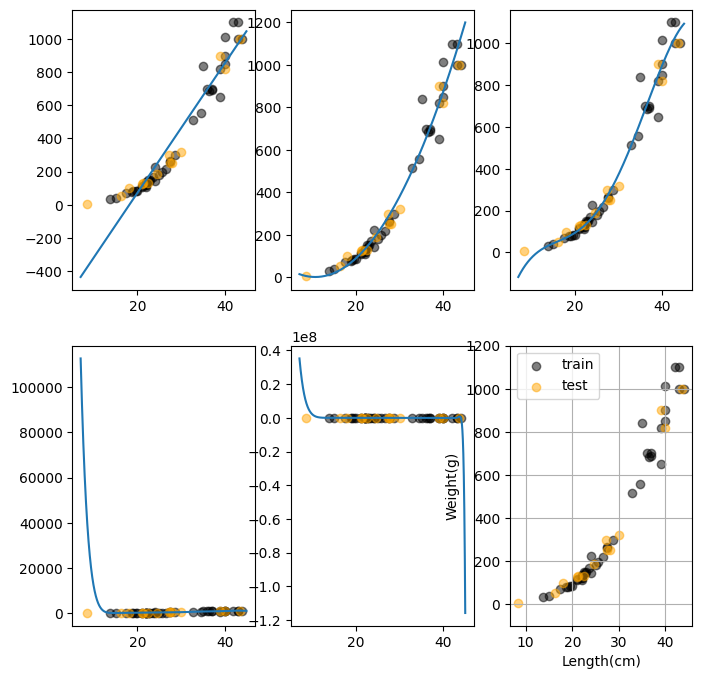

In [69]:
fig,axes=plt.subplots(nrows=2,ncols=3,figsize=(8,8))
axes=axes.flatten()
#
# x 길이 y 무게
# 훈련셋 산점도
plt.scatter(x_train,y_train, color='black',alpha=0.5,label='train')

# 테스트 셋 산점도
plt.scatter(x_test,y_test, color='orange',alpha=0.5,label='test')

# 고차항들을 포함하는 선형회귀 방정식을 찾기 위해서
# PolynomialFeatures에서 사용할 degree(차수) 값들
degrees = (1,2,5,10,50)
for i,d in enumerate(degrees):
  ax=axes[i]
  # 훈련셋 산점도
  ax.scatter(x_train,y_train, color='black',alpha=0.5,label='train')

  # 테스트 셋 산점도
  ax.scatter(x_test,y_test, color='orange',alpha=0.5,label='test')
  # Pipeline 객체 생성
  pipe=Pipeline(steps=[('poly',PolynomialFeatures(degree=d, include_bias=False)),
   ('scaler',StandardScaler()),
    ('regressor',LinearRegression())])
  # 모델 훈련
  pipe.fit(X=x_train,y=y_train)

  # 훈련 셋, 테스트 셋 의 MSE 출력
  print(f'---------degree ={d}----------')
  train_pred=pipe.predict(x_train) # 훈련 셋 예측값
  train_mse=mean_squared_error(y_true=y_train,y_pred=train_pred)

  print('훈련 셋 mse:',train_mse)

  test_pred=pipe.predict(x_test) # 테스트 셋 예측값
  test_mse=mean_squared_error(y_true=y_test,y_pred=test_pred)

  print('테스트 셋 mse:',test_mse)

  # 선형회귀 함수 시각화
  x_val =np.arange(7,45,0.0001).reshape((-1,1)) # 행은 몇개인지몰라서 -1 , 컬럼은 1개 나머지-1
                                      #(n,1)shape의 2d array
  y_val =pipe.predict(x_val)
  ax.plot(x_val,y_val,label=f'degree{d}')


plt.legend()
plt.grid()
plt.xlabel('Length(cm)')
plt.ylabel('Weight(g)')
plt.ylim((-100,1200)) # y축을 어디서부터 어디까지
plt.show()

---------degree =1----------
훈련 셋 mse: 7422.953552609778
테스트 셋 mse: 17590.265977889165
---------degree =2----------
훈련 셋 mse: 3617.9917403639633
테스트 셋 mse: 2248.9974694392554
---------degree =5----------
훈련 셋 mse: 3216.6113933040733
테스트 셋 mse: 1753.0984158595472
---------degree =10----------
훈련 셋 mse: 2287.976500994845
테스트 셋 mse: 133926093.37648238
---------degree =50----------
훈련 셋 mse: 1242.3671485244474
테스트 셋 mse: 7683897194550.778


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


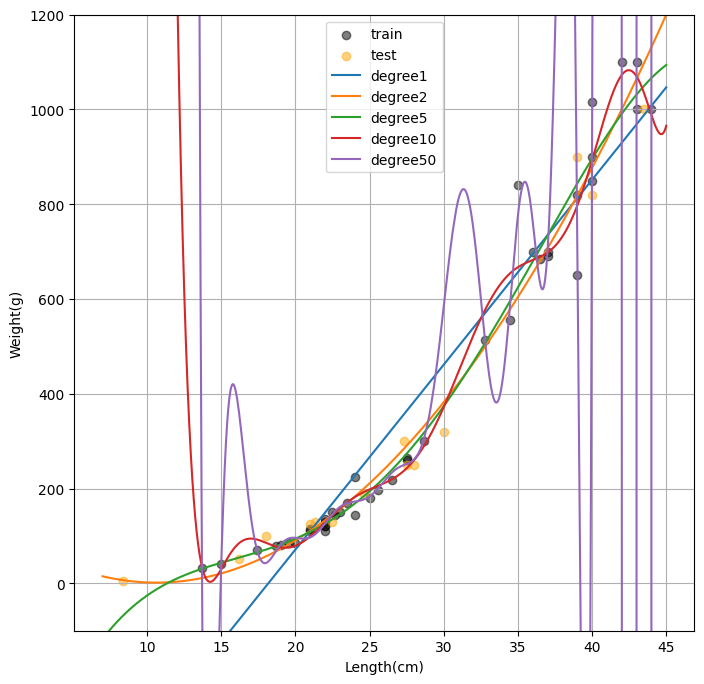

In [70]:
plt.figure(figsize=(8,8))
# x 길이 y 무게
# 훈련셋 산점도
plt.scatter(x_train,y_train, color='black',alpha=0.5,label='train')

# 테스트 셋 산점도
plt.scatter(x_test,y_test, color='orange',alpha=0.5,label='test')

# 고차항들을 포함하는 선형회귀 방정식을 찾기 위해서
# PolynomialFeatures에서 사용할 degree(차수) 값들
degrees = (1,2,5,10,50)
for d in degrees:
  # Pipeline 객체 생성
  pipe=Pipeline(steps=[('poly',PolynomialFeatures(degree=d, include_bias=False)),
   ('scaler',StandardScaler()),
    ('regressor',LinearRegression())])
  # 모델 훈련
  pipe.fit(X=x_train,y=y_train)

  # 훈련 셋, 테스트 셋 의 MSE 출력
  print(f'---------degree ={d}----------')
  train_pred=pipe.predict(x_train) # 훈련 셋 예측값
  train_mse=mean_squared_error(y_true=y_train,y_pred=train_pred)

  print('훈련 셋 mse:',train_mse)

  test_pred=pipe.predict(x_test) # 테스트 셋 예측값
  test_mse=mean_squared_error(y_true=y_test,y_pred=test_pred)

  print('테스트 셋 mse:',test_mse)

  # 선형회귀 함수 시각화
  x_val =np.arange(7,45,0.0001).reshape((-1,1)) # 행은 몇개인지몰라서 -1 , 컬럼은 1개 나머지-1
                                      #(n,1)shape의 2d array
  y_val =pipe.predict(x_val)
  plt.plot(x_val,y_val,label=f'degree{d}')


plt.legend()
plt.grid()
plt.xlabel('Length(cm)')
plt.ylabel('Weight(g)')
plt.ylim((-100,1200)) # y축을 어디서부터 어디까지
plt.show()

차수가 높아질 수록 선형회귀 함수는 훈련 셋에 더 많이 과대적합(over-fitting)되는 모습을 볼 수 있다.

과대적합이 커지면 훈련 셋에서는 오차가 적을지라도 , 훈련되지 않은 데이터들은 오차가 매우 클 수 있다. 일반화 성능이 떨어짐.

과대적합의 크기를 줄일 수 있는 방법을 고려 -> 규제(regularization)

# 규제(Regularization)

* 머신 러닝의 목적은 비용 함수(cost function)&손실 함수(loss function)를 최소화 하는 것.
* 선형회귀(linear regression)의 목적은 MSE(mean squared error)를 최소로 하는 계수들($ w_0, w_1, w_2, ..., w_n $)을 찾는 것.
  * 선형회귀의 비용함수는 MSE(w). (w=독립변수)



*   머신 러닝의 목적은 비용 함수(cost function)/손실 함수(loss function)을 최소화하는 것.


*   선형 회귀(linear regression)의 목적은 MSE(mean squared errors)를 최소로 만드는 계수들($w_0, w_1, w_2, ..., w_m$)을 찾는 것. 즉, 선형 회귀의 비용 함수는 $ MSE(w) $ .
$$
J(w) = MSE(w)
     = \dfrac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y_i})^2
     = \dfrac{1}{N} \sum_{i=1}^{N} (y_i - (w_0 + \sum_{j=1}^{m} x_{ij} \cdot w_{j}))^2
$$
    *   $N$: 샘플의 개수(특성 행렬의 row의 개수)
    *   $m$: 특성의 개수(특성 행렬의 column의 개수)
    *   $y_i$: $i$번째 샘플의 실젯값
    *   $\hat{y_i}$: $i$번째 샘플의 예측값
    *   $x_{ij}$: $i$번째 샘플의 $j$번째 특성 값
    *   $w_j$: $j$번째 특성에 곱해주는 계수(기울기)

*   Ridge(`l2`) 규제의 목적은 아래의 비용 함수를 최소로 만드는 계수들($w_0, ..., w_m$)을 찾는 것.

$$
J(w) = MSE(w) + \dfrac{\alpha}{2} \mid\mid w \mid\mid ^2
$$

> Ridge 규제의 효과는 고차항들의 계수(coefficients, 기울기)를 작게 만들어서 곡선의 기울기를 완만하게 만들어 주게 됨. overfitting(과대적합)을 줄여주게 됨.

*   Lasso(`l1`) 규제의 목적은 아래의 비용 함수를 최소로 만드는 계수들($w_0, ..., w_m$)을 찾는 것.

$$
J(w) = MSE(w) + \alpha \mid\mid w \mid\mid
$$

> Lasso 규제는 중요하지 않은 고차항들의 계수를 0으로 만들어 줌으로써, 곡선을 완만하게 만들어 주는 효과가 생김. 과대적합을 줄여주는 효과.

*   ElasticNet 규제의 목적은 아래의 비용 함수를 최소로 만드는 계수들($w_0, ..., w_m$)을 찾는 것.

$$
J(w) = MSE(w) + r \alpha \mid\mid w \mid\mid
              + \dfrac{1 - r}{2} \alpha \mid\mid w \mid\mid ^2
$$

> ElasticNet은 Ridge 규제와 Lasso 규제의 효과를 모두 가지고 있음.

*   Ridge, Lasso에서 $\alpha$ 값이 크면 규제가 강해지고, $\alpha$ 값이 작으면 규제가 약해짐($ \alpha \ge 0 $).
    * $ \alpha$값이 커지면, 규제가 커지고, 손실이 증가, 과대적합이 줄어든다.
    * $\alpha$값이 작아지면, 규제가 작아지고, 손실이 줄고, 좋은훈련, 과대적합이 커진다.
*   ElasticNet에서 $\alpha$는 규제의 크기를 의미하고, $r$은 `l1` 규제의 비율($0 \le r \le 1$)을 의미함.


In [71]:
# 알파값에 따른 손실유무 물어보기 마지막 세줄이다
# 손실이크다 = 오차가크다
# 테스트셋도 커진다?  규제가 뭐야? 이거왜적은거지?


## 시각화 함수 정의

* 훈련 셋 산점도
* 테스트 셋 산점도
* 선형회귀 함수 시각화
* 결정계수(R2 score) 출력

In [72]:
def visualize_regression(x_train,x_test,y_train,y_test,degrees,estimator):
  plt.figure(figsize=(8,8))

  # 훈련 셋 산점도
  plt.scatter(x_train,y_train,color='black',alpha=0.5,label='train')
  # 테스트 셋 산점도
  plt.scatter(x_test,y_test,color='orange',alpha=0.5,label='test')

  for d in degrees:
    # Pipeline 객체 생성
    pipe=Pipeline(steps=[('poly',PolynomialFeatures(degree=d,include_bias=False)),
     ('scaler',StandardScaler()),('regressor',estimator)])

    # 모델 훈련
    pipe.fit(x_train,y_train)
    train_score=pipe.score(x_train,y_train) # 훈련 셋의 결정계수
    test_score=pipe.score(x_test,y_test) # 테스트 셋의 결정계수
    print(f'degree={d}: {train_score}(Train) / {test_score}(Test)')

    # 선형회귀의 함수 시각화
    x_val=np.arange(7,45,0.0001).reshape((-1,1))
    y_val=pipe.predict(x_val)
    plt.plot(x_val,y_val,label=f'degree={d}')



  plt.grid()
  plt.legend()
  plt.xlabel('length(cm)')
  plt.ylabel('weight(g)')
  plt.ylim((-100,1200))
  plt.show()

## L2 규제(Ridge)

degree=1: 0.9393380341955502(Train) / 0.836127969609232(Test)
degree=2: 0.9619389326333372(Train) / 0.9347719209841489(Test)
degree=5: 0.9675257933461249(Train) / 0.9665833996552663(Test)
degree=50: 0.9739229136053733(Train) / 0.9813385255457557(Test)


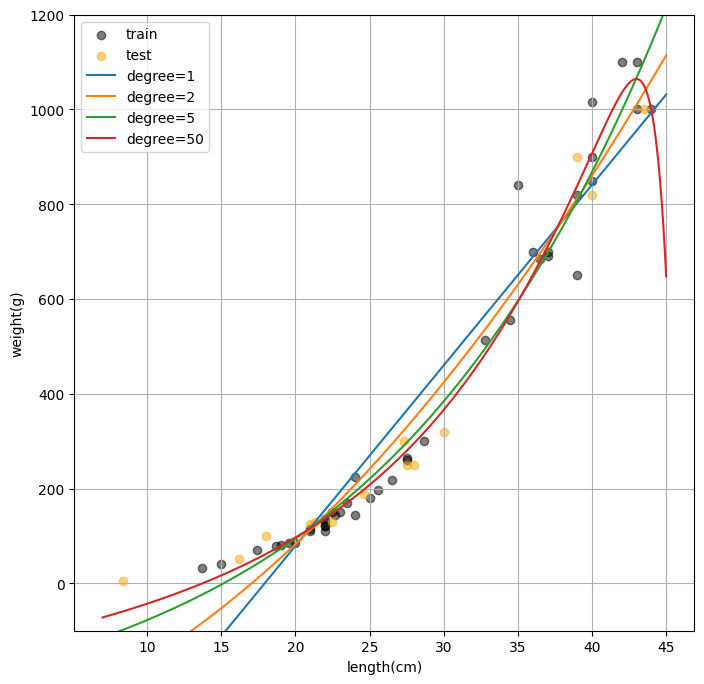

In [73]:
degrees=(1,2,5,50)
estimator=Ridge()
# #(alpha: float = 1, 2차항앞에곱해지는계
#     *,
#     fit_intercept: bool = True,
#     copy_X: bool = True,
#     max_iter: Any | None = None,
#     tol: float = 0.0001,
#     solver: str = "auto",
#     positive: bool = False,
#     random_state: Any | None = None
# )
visualize_regression(x_train,x_test,y_train,y_test,degrees,estimator)
#

## L1 규제(Lasso)

degree=1: 0.9398382302602472(Train) / 0.8262705448946932(Test)
degree=2: 0.9682046094058255(Train) / 0.9632610688126504(Test)
degree=5: 0.9692636157789123(Train) / 0.9718691066691287(Test)
degree=50: 0.9747331384703934(Train) / 0.9827585864116039(Test)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.007e+02, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(


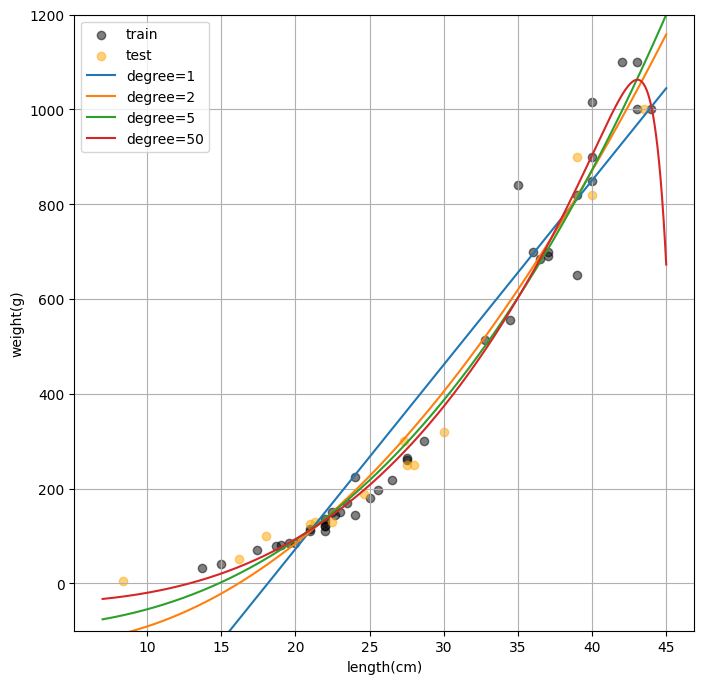

In [74]:
visualize_regression(x_train,x_test,y_train,y_test,degrees,Lasso())

## ElasticNet

degree=1: 0.8348047834365431(Train) / 0.8425462812915511(Test)
degree=2: 0.9179731022680415(Train) / 0.9211902563521128(Test)
degree=5: 0.9574099753809557(Train) / 0.9741613969257316(Test)
degree=50: 0.9610659368865341(Train) / 0.9817137006795826(Test)


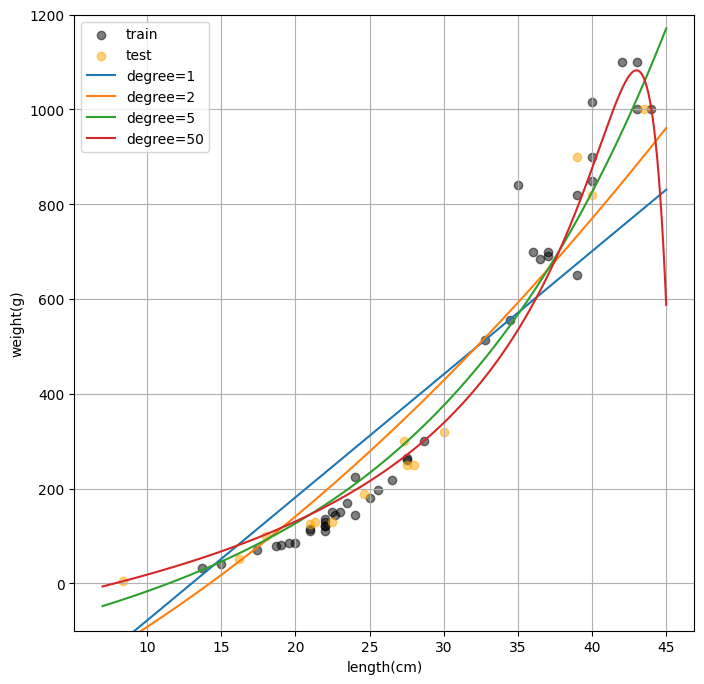

In [75]:
visualize_regression(x_train,x_test,y_train,y_test,degrees,ElasticNet())

# 하이퍼 파라미터(Hyper-parameter) 튜닝

* 모델 파라미터(model parameter):가중치 , 머신 러닝 알고리즘에서 만들어진 **수학적인 모델**의 비용(손실)함수를 최소화하도록 만드는 파라미터들. 머신 러닝 알고리즘이 스스로 찾아내는 값들
    * (예) 선형 회귀: 절편w0, 기울기w1, ...(절편, 인터셉트, 계수, 기울기, coef)
* 하이퍼 파라미터(hyper-parameter): 머신 러닝 알고리즘에서 개발자 바꿘가면서 테스트 하는 값들.
    * KNN 알고리즘 - k(최근접 이웃의 개수)
    * PolynomialFeatures - degree(차수)
    * 규제(L2ridge, L1lasso, ElasticNet) - alpha(규제의 크기), l1_ratio(Elast..에만있다,L1규제의 비율)    
* 규제 크기(alpha)에 따른 결정계수(R2 score) 변화
    * Weight ~ Length + Diagonal + Height + Width
    * PolynomialFeatures(degree=5) 사용
    * StandardScaler 사용    
    * Ridge vs Lasso vs ElasticNet: alpha=(0.001, 0.01, 0.1, 1.0, 10, 100)
    * 훈련 셋/ 테스트 셋 에서 결정계수 계산, 시각화

In [76]:
x= perch[perch.columns[2:]].to_numpy()

In [77]:
y=perch['Weight'].to_numpy()

In [78]:
x[:5]

array([[ 8.4   ,  8.8   ,  2.112 ,  1.408 ],
       [13.7   , 14.7   ,  3.528 ,  1.9992],
       [15.    , 16.    ,  3.824 ,  2.432 ],
       [16.2   , 17.2   ,  4.5924,  2.6316],
       [17.4   , 18.5   ,  4.588 ,  2.9415]])

In [79]:
y[:5]

array([ 5.9, 32. , 40. , 51.5, 70. ])

In [80]:
# 훈련 셋, 테스트 셋 나누기
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [81]:
alphas = [10 **x for x in range(-3,3)]
print(alphas)
np.log10(alphas)

[0.001, 0.01, 0.1, 1, 10, 100]


array([-3., -2., -1.,  0.,  1.,  2.])

In [82]:
def visualize_r2_score(estimator):
  alphas = [10 **x for x in range(-3,3)] # 규제 크기들의 리스트
  train_scores=[] # 훈련 셋에서의 결정계수를 저장하기 위한 리스트.
  test_scores=[] # 테스트 셋에서의 결정계수를 저장하기 위한 리스트.
  for a in alphas:
    if estimator =='l1':
      regressor = Lasso(alpha=a)
    elif estimator =='l2':
      regressor = Ridge(alpha=a)
    elif estimator =='elastic':
      regressor = ElasticNet(alpha=a)
    else:
      raise ValueError('estimator는 "l1", "l2" 또는 "elastic"이어야 함')
    # pipeline 객체 생성
    # 모델 훈련
    # 훈련 셋 결정계수를 train_scores에 추가
    # 테스트 셋 결정계수를 test_scores에 추가
    pipe=Pipeline(steps=[('poly',PolynomialFeatures(degree=5,include_bias=False)),('scaler',StandardScaler()),('reg',regressor)])
    pipe.fit(x_train,y_train)
    tr_r2=pipe.score(x_train,y_train)
    train_scores.append(tr_r2)
    te_r2=pipe.score(x_test,y_test)
    test_scores.append(te_r2)
    # train_scores.append(pipe.score(x_train,y_train))
    # test_scores.append(pipe.score(x_test,y_test))
    # print(f'alpha={a}: train({train_scores}) / test({test_scores})')
    print(f'alpha={a}: train({tr_r2:.3f}) / test({te_r2:.3f})')
  # train_scores 선그래프
  # test_scores 선그래프
  plt.figure(figsize=(8,8))
  # plt.plot(alphas,train_scores)
  # plt.plot(alphas,test_scores)
  # plt.xscale('log')"linear", "log", "function" 가능
  plt.plot(np.log10(alphas),train_scores,'bo-',label='train_score')
  plt.plot(np.log10(alphas),test_scores,'ro:',label='test_score')
  plt.legend()
  plt.grid()
  plt.xlabel('alpha(log scale)')
  plt.ylabel('r2 score')
  # plt.xlabel('sdf')
  # plt.plot(,label='test_score')
  plt.show()

alpha=0.001: train(0.991) / test(0.982)
alpha=0.01: train(0.991) / test(0.983)
alpha=0.1: train(0.990) / test(0.982)
alpha=1: train(0.990) / test(0.980)
alpha=10: train(0.989) / test(0.983)
alpha=100: train(0.908) / test(0.909)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.223e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.931e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.286e+03, tolerance: 5.183e

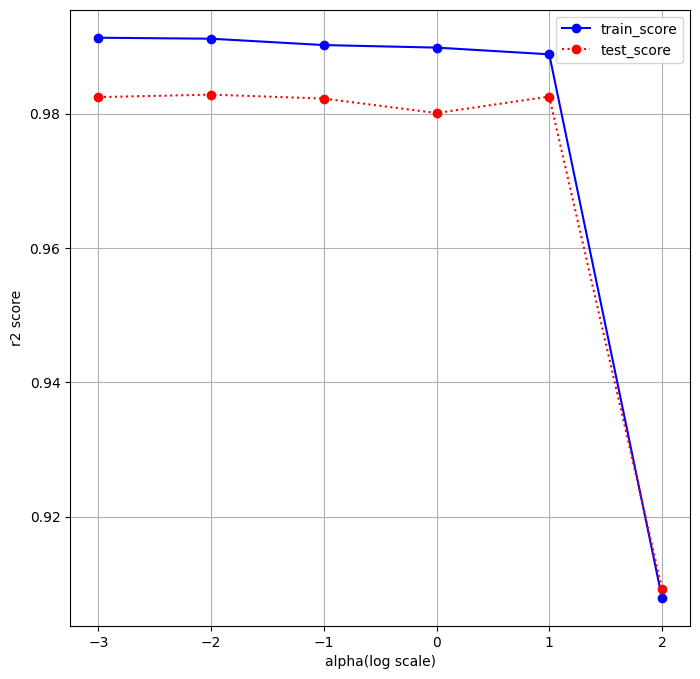

In [83]:
visualize_r2_score('l1')

alpha=0.001: train(0.995) / test(0.881)
alpha=0.01: train(0.993) / test(0.968)
alpha=0.1: train(0.991) / test(0.983)
alpha=1: train(0.990) / test(0.981)
alpha=10: train(0.989) / test(0.975)
alpha=100: train(0.985) / test(0.962)


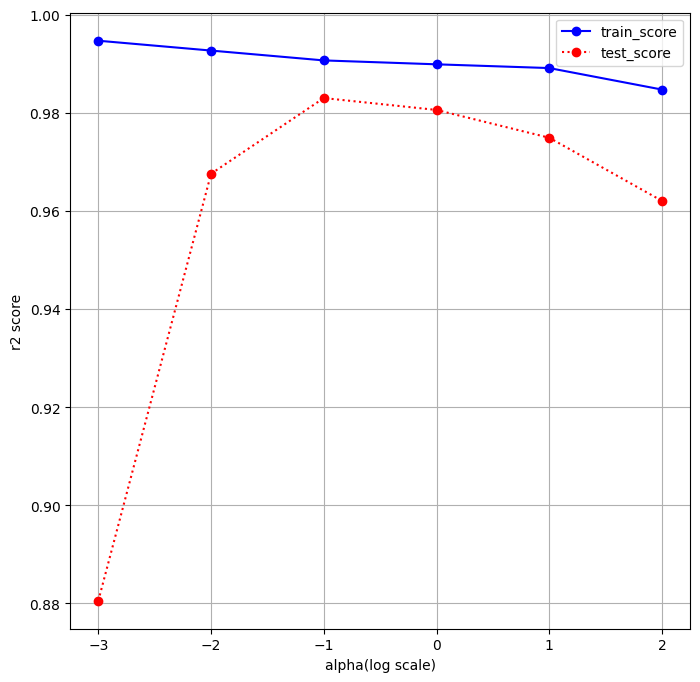

In [84]:
visualize_r2_score('l2')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.363e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.377e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.638e+04, tolerance: 5.183e

alpha=0.001: train(0.991) / test(0.983)
alpha=0.01: train(0.990) / test(0.983)
alpha=0.1: train(0.990) / test(0.979)
alpha=1: train(0.988) / test(0.972)
alpha=10: train(0.981) / test(0.962)
alpha=100: train(0.830) / test(0.842)


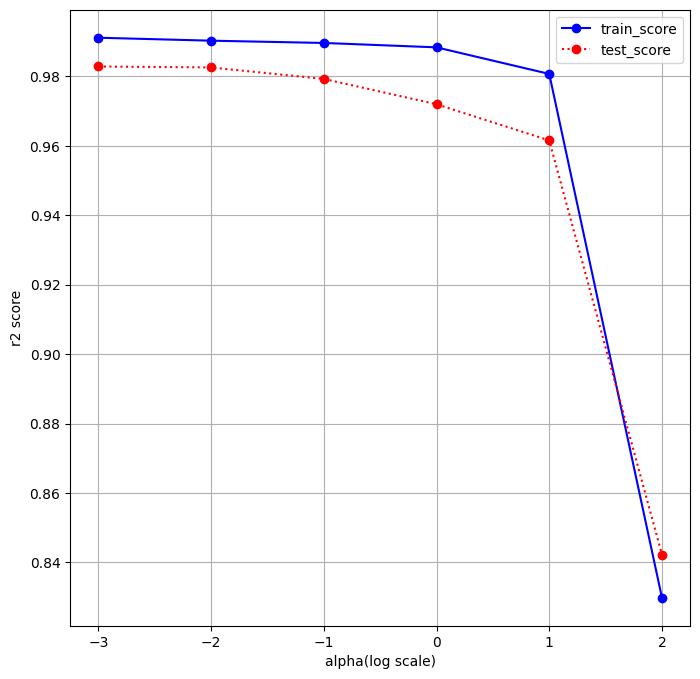

In [85]:
visualize_r2_score('elastic')